In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

In [ ]:
np.random.seed(42)
X,y = make_circles(n_samples=500,factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.5, random_state=42)


In [10]:
y

array([1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((250, 2), (250, 2), (250,), (250,))

Text(0, 0.5, 'Feature 2')

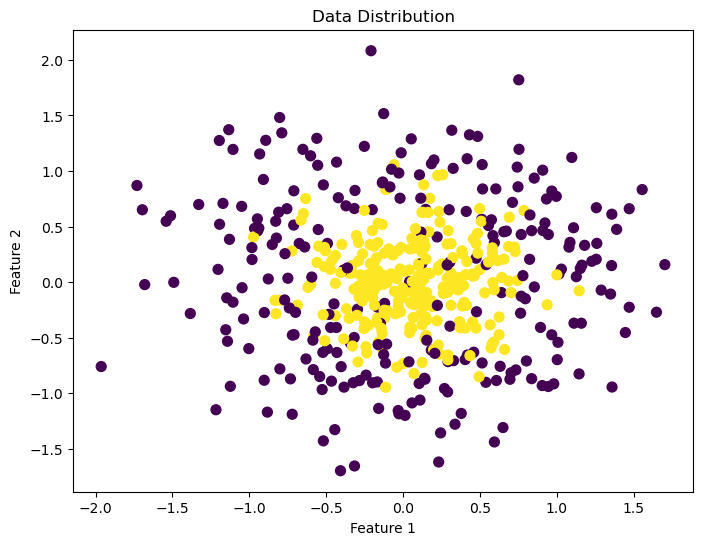

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1],c = y ,s=50, cmap='viridis')
plt.title('Data Distribution')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

### Visualizing Decision Tree Classifier: Low Bias, High Variance The plot below illustrates the decision boundary of a Decision Tree Classifier. Decision trees are low bias models as they can perfectly fit the training data. However, they are high variance models, meaning they are sensitive to small changes in the training data, which can lead to overfitting. This is evident in the complex and irregular decision boundary.


Text(0, 0.5, 'Feature 2')

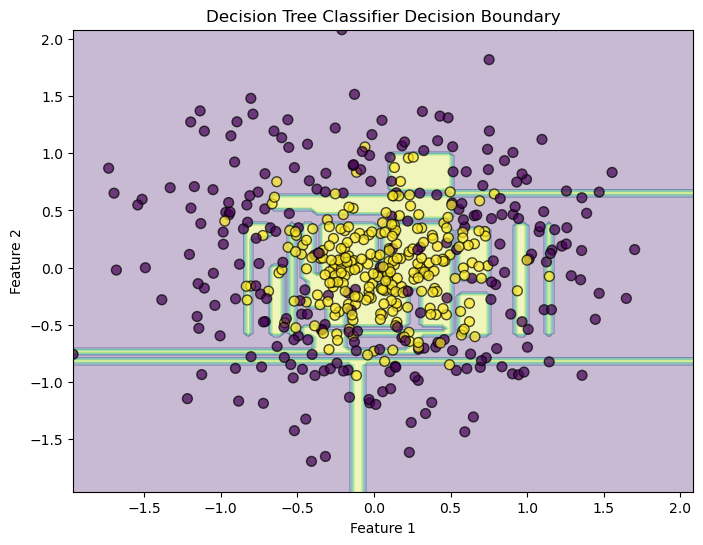

In [11]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier( random_state=42)
dtree.fit(X_train, y_train)

plt.figure(figsize=(8, 6))
x_range = np.linspace(X.min(), X.max(), 100)
x1, x2 = np.meshgrid(x_range, x_range)
y_pred = dtree.predict(np.c_[x1.ravel(), x2.ravel()])
y_pred = y_pred.reshape(x1.shape)
plt.contourf(x1, x2, y_pred, cmap='viridis', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolor='k',alpha=0.7)
plt.title('Decision Tree Classifier Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')


### Random Forest Classifier: Low Bias, Low Variance Random Forest is an ensemble learning method that combines multiple decision trees to improve performance. It is a low bias model because it reduces underfitting by averaging the predictions of multiple trees. Additionally, it is a low variance model because the aggregation of predictions from multiple trees reduces the impact of individual tree overfitting. This balance makes Random Forest a robust and reliable model for various datasets.

Text(0, 0.5, 'Feature 2')

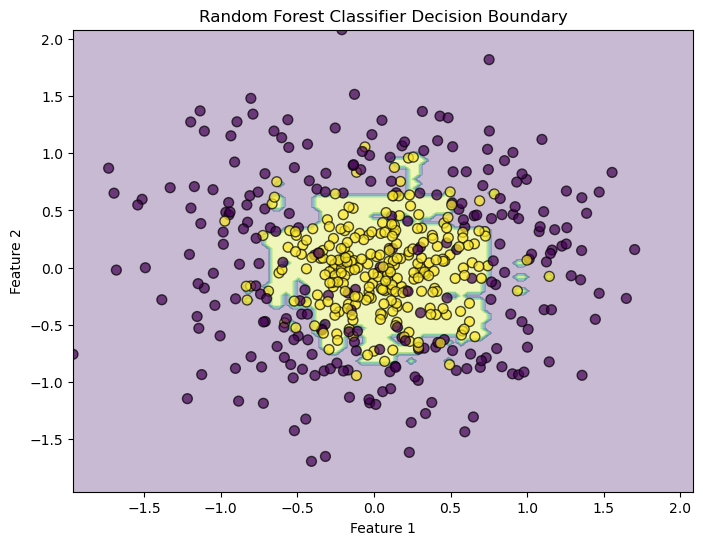

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)
plt.figure(figsize=(8, 6))
x_range = np.linspace(X.min(), X.max(), 100)
x1, x2 = np.meshgrid(x_range, x_range)
y_pred = rf.predict(np.c_[x1.ravel(), x2.ravel()])
y_pred = y_pred.reshape(x1.shape)
plt.contourf(x1, x2, y_pred, cmap='viridis', alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis', edgecolor='k',alpha=0.7)
plt.title('Random Forest Classifier Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

## SAME FOR REGRESSION

In [32]:
n_train = 150 
n_test = 1000
noise = 0.1

def f(x):
    x = x.ravel()
    return np.exp(-x**2)+1.5 * np.exp(-(x-2)**2)
    # return np.exp(-x**2) * np.sin(5*x)
def generate_data(n_samples, noise):
    X = np.random.rand(n_samples, 1) * 10 - 5
    X = np.sort(X, axis=0).ravel()
    y = np.exp(-X**2) + 1.5 * np.exp(-(X-2)**2) + np.random.normal(0.0,noise , n_samples) 
    X = X.reshape((n_samples, 1))
    return X, y

In [33]:
X_train, y_train = generate_data(n_train, noise)
X_test, y_test = generate_data(n_test, noise)

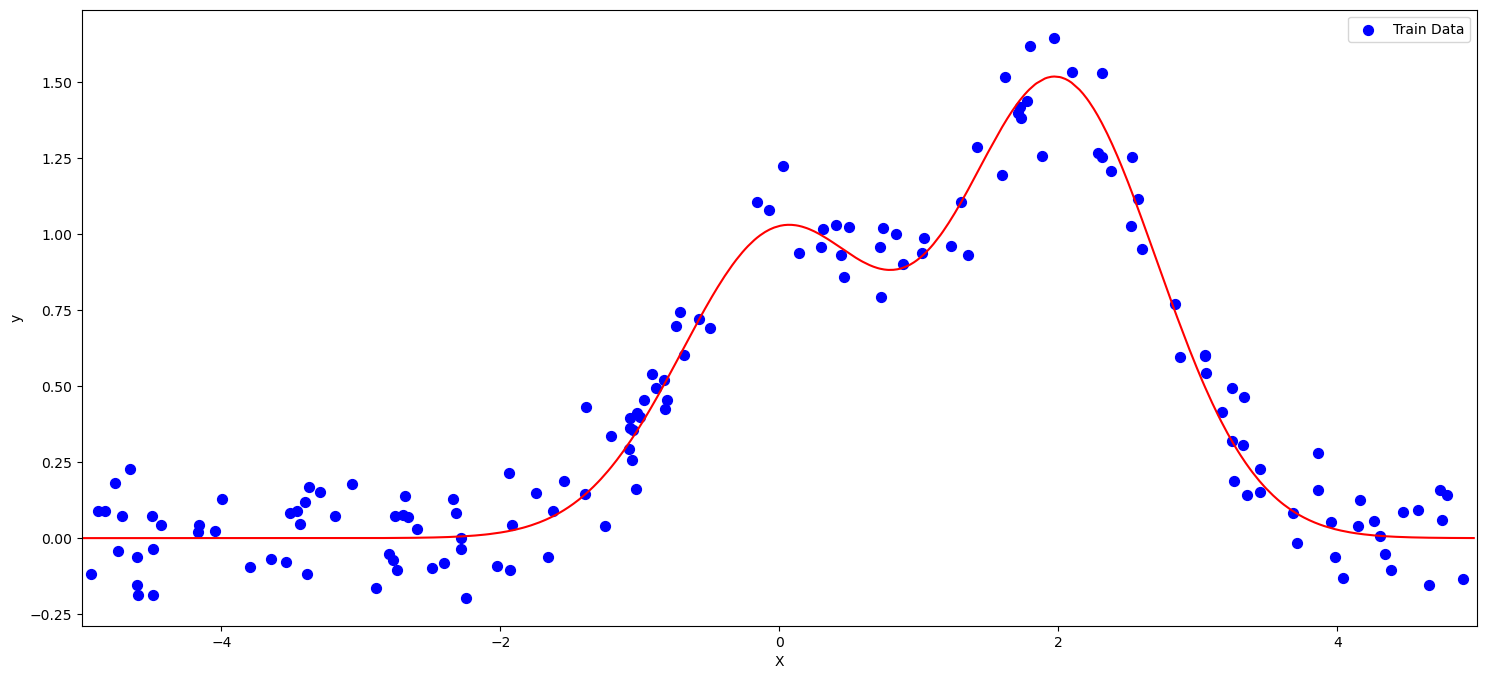

In [34]:
plt.figure(figsize=(18, 8))
plt.scatter(X_train, y_train, color='blue', label='Train Data', s=50)
plt.plot(X_test, f(X_test), "r")
plt.xlim(-5, 5)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

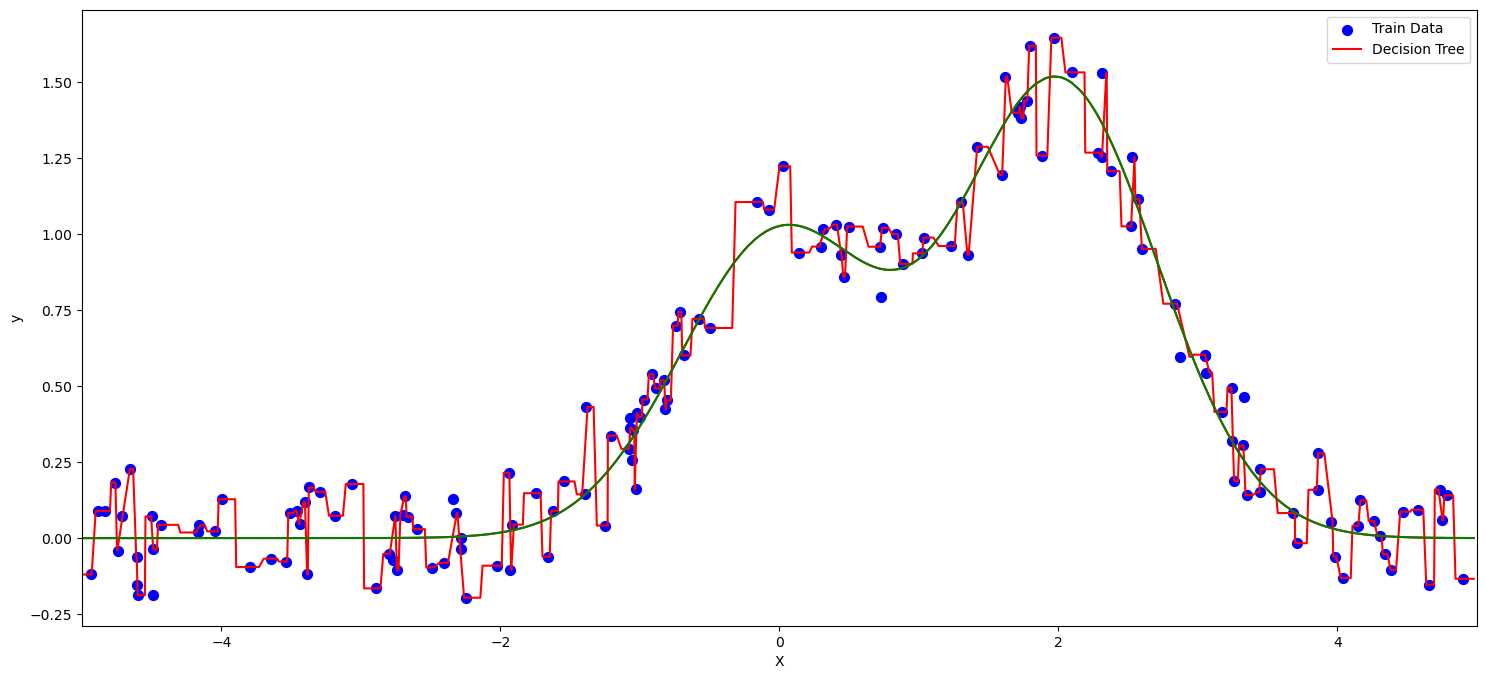

In [39]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor( random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(18, 8))
plt.scatter(X_train, y_train, color='blue', label='Train Data', s=50)
plt.plot(X_test, f(X_test), "r")
plt.plot(X_test, y_pred, "r", label='Decision Tree')
plt.plot(X_test, f(X_test), "g")
plt.xlim(-5, 5)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

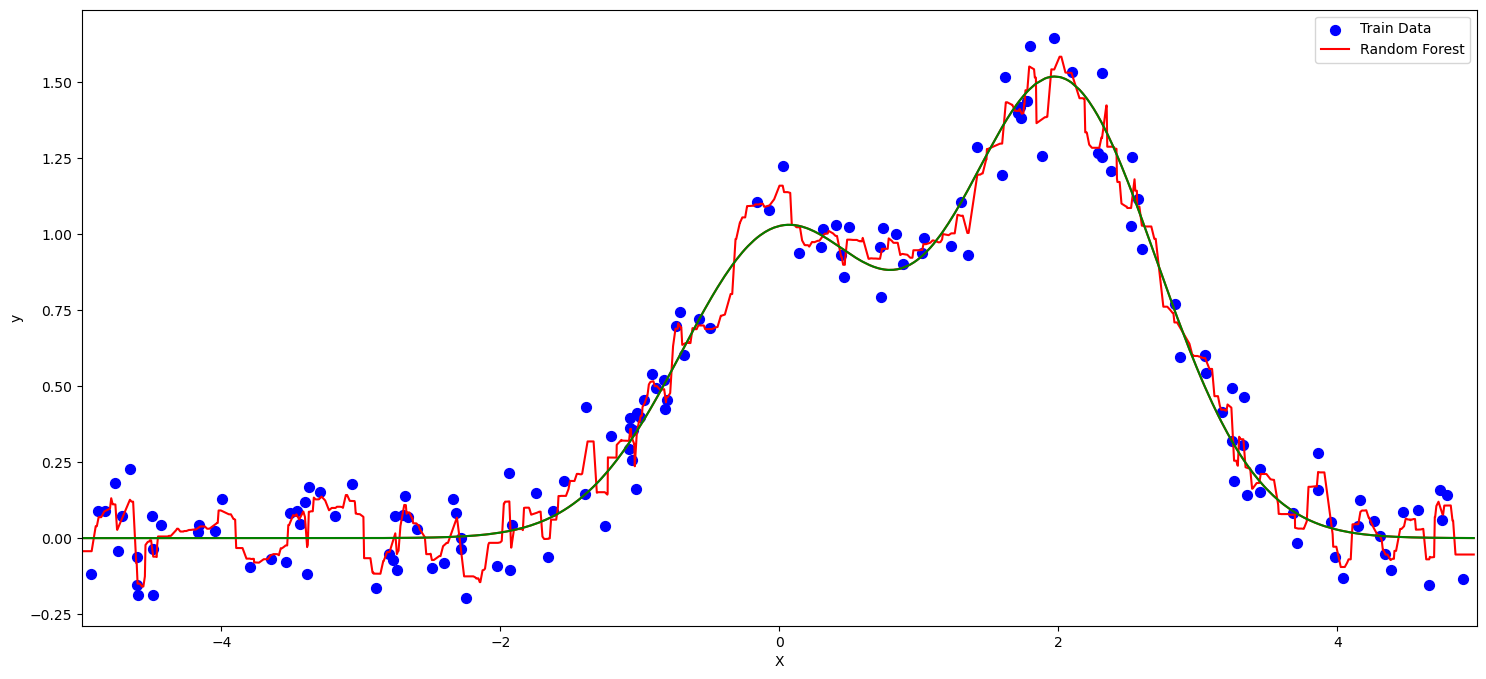

In [41]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=500, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(18, 8))
plt.scatter(X_train, y_train, color='blue', label='Train Data', s=50)
plt.plot(X_test, f(X_test), "r")
plt.plot(X_test, y_pred, "r", label='Random Forest')
plt.plot(X_test, f(X_test), "g")
plt.xlim(-5, 5)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()